# 🖼️ Visualizing and Understanding CNNs: A Guide for Data Scientists

Understanding how a Convolutional Neural Network (CNN) "sees" and makes decisions is crucial for debugging, improving, and trusting a model. This notebook provides a detailed explanation and code examples for various CNN visualization techniques.

-----

## 🔍 Visualization of Kernels

Kernels (or filters) are the building blocks of a CNN. They are small matrices that convolve across the input image to extract features. Visualizing them can reveal what features a layer is looking for. In the first layer, kernels often learn to detect basic patterns like edges and colors.

### 📌 **VGG16 – What is it?**

* **VGG16** is a deep CNN architecture that has **16 layers** (13 convolutional layers and 3 fully connected layers).
* It was proposed by the Visual Geometry Group (VGG) at the University of Oxford.
* It’s widely used in computer vision tasks like image classification, object detection, and feature extraction.

---

### ✅ **Understanding the parameters**

1. **`weights='imagenet'`**

   * Loads the model pre-trained on the **ImageNet dataset**.
   * ImageNet contains over **14 million images** and **1000 classes**, like dogs, cars, furniture, etc.
   * Using pre-trained weights means the model already “knows” how to detect basic patterns like edges, textures, shapes, and object parts.

2. **`include_top=False`**

   * Excludes the final fully connected layers (the “top” classification part).
   * This is useful when you want to use the CNN as a **feature extractor** rather than for classification.
   * You can add your own classification or regression layers depending on your task.
   * **Why use `include_top=False`?**

       * You want to adapt VGG16 for your own dataset with different classes.
       * You need the convolutional base to extract features from images without committing to the original 1000 ImageNet classes.
      * It allows transfer learning by adding custom layers on top.
---

### 📌 Topics Discussed

* **Transfer Learning** → Using pre-trained models and adapting them to new tasks.
* **Feature Extraction** → Using CNN layers to extract informative patterns.
* **Fine-Tuning** → Training some of the pre-trained layers on new data to improve performance.

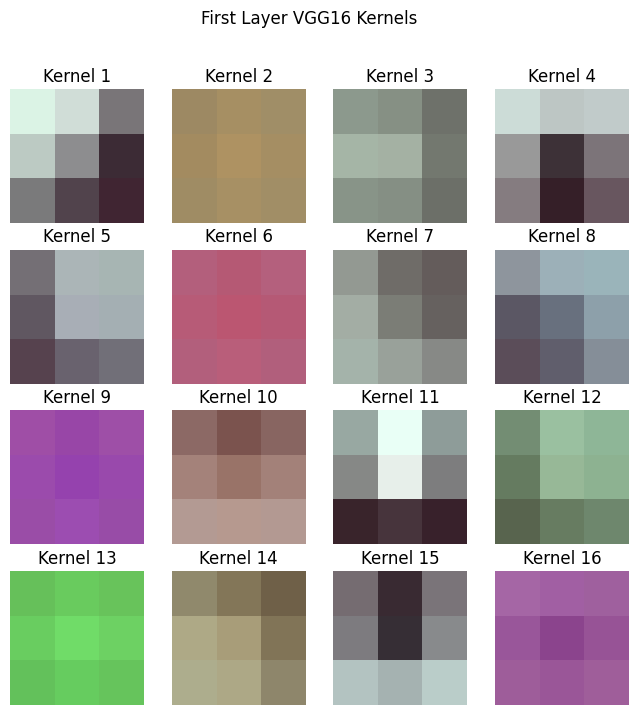

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

# Load a pre-trained VGG16 model
model = VGG16(weights='imagenet', include_top=False)

# Get the first convolutional layer with weights
first_conv_layer = None
for layer in model.layers:
    if len(layer.get_weights()) > 0:
        first_conv_layer = layer
        break

if first_conv_layer:
    first_layer_weights = first_conv_layer.get_weights()[0]

    # Normalize weights for visualization
    min_val, max_val = first_layer_weights.min(), first_layer_weights.max()
    first_layer_weights = (first_layer_weights - min_val) / (max_val - min_val)

    # Plot the first 16 kernels
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i, ax in enumerate(axes.flat):
        if i < first_layer_weights.shape[3]:
            # Each kernel has 3 channels for RGB
            kernel = first_layer_weights[:, :, :, i]
            ax.imshow(kernel)
            ax.axis('off')
            ax.set_title(f'Kernel {i+1}')
    plt.suptitle('First Layer VGG16 Kernels')
    plt.show()
else:
    print("Could not find a layer with weights in the model.")

The kernels in the first layer often look like small, abstract patterns, revealing the low-level features the network is designed to detect.

-----

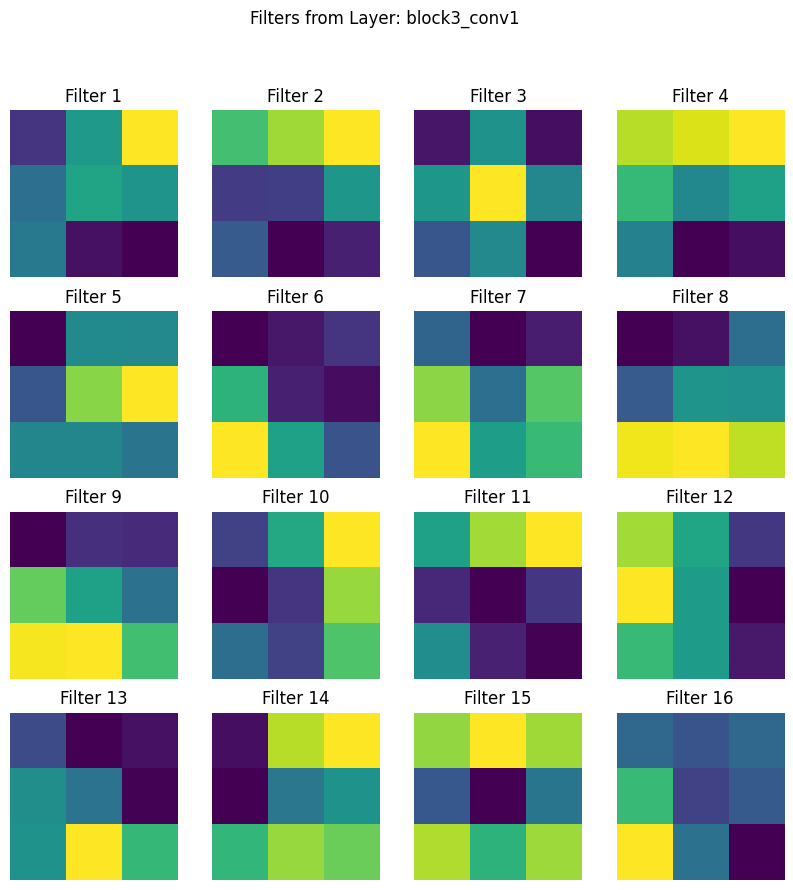

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt

# Load pre-trained VGG16 without the top classification layer
model = VGG16(weights='imagenet', include_top=False)

# Find a deeper convolutional layer (e.g., block3_conv1 or block4_conv1)
layer_name = 'block3_conv1'  # You can also try 'block4_conv1' or others
conv_layer = model.get_layer(name=layer_name)

# Extract the weights of the selected layer
weights = conv_layer.get_weights()[0]  # Shape: (kernel_size, kernel_size, input_channels, output_channels)

# Normalize weights for visualization
min_val = weights.min()
max_val = weights.max()
weights = (weights - min_val) / (max_val - min_val)

# Plot the first 16 filters
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[3]:
        # Extract the i-th filter
        kernel = weights[:, :, :, i]

        # For visualization, take only one channel or average across channels
        if kernel.shape[2] == 3:
            # For RGB, average the channels
            img = np.mean(kernel, axis=2)
        else:
            img = kernel[:, :, 0]

        ax.imshow(img, cmap='viridis')
        ax.axis('off')
        ax.set_title(f'Filter {i+1}')
plt.suptitle(f'Filters from Layer: {layer_name}')
plt.show()


### ✅ **What the Above Code Does**

The provided code performs the following:

1. **Loads a pre-trained VGG16 model**

   * `VGG16(weights='imagenet', include_top=False)` loads the model with weights trained on the ImageNet dataset.
   * `include_top=False` means we exclude the final classification layers so that we can access convolutional layers and their filters.

2. **Selects a deeper convolutional layer (`block3_conv1`)**

   * Layers like `block3_conv1` are deeper in the network and detect more complex patterns like textures and shapes.

3. **Extracts the convolutional filters (kernels)**

   * These filters are learned during training on ImageNet and are responsible for detecting edges, blobs, corners, and other patterns in images.

4. **Normalizes the filter values**

   * It scales the filter values between 0 and 1 for proper visualization.

5. **Visualizes the first 16 filters**

   * It averages across color channels (if needed) and plots the spatial pattern each filter detects.

---



### ✅ **What is VGG16 and ImageNet?**

* **VGG16** is a convolutional neural network architecture introduced by the Visual Geometry Group at Oxford.

* It consists of 16 layers (13 convolutional and 3 fully connected layers).

* It is widely used because of its simplicity and effectiveness.

* **ImageNet** is a large dataset containing over 14 million images labeled across 20,000+ categories.

* Models like VGG16 are **pre-trained on ImageNet**, meaning they've learned to detect a variety of features by training on this large dataset.

This pre-trained model can be used for:

* Feature extraction
* Transfer learning
* Image recognition tasks

---


### ✅ **A Small Snippet to Demonstrate ImageNet Prediction Using VGG16**

Here’s how you can use VGG16 with ImageNet weights to classify an image:


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 910ms/step


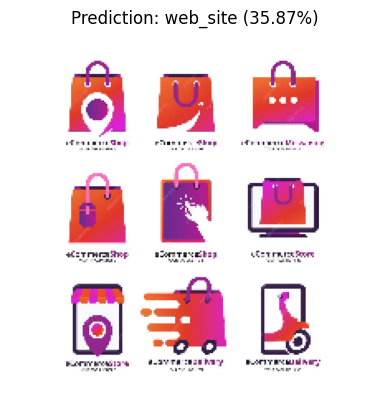

1: web_site (35.87%)
2: remote_control (5.57%)
3: envelope (4.64%)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, vgg16
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# Load the pre-trained VGG16 model including the top layers for classification
model = VGG16(weights='imagenet')

# Load a sample image (change path to an actual image)
img_path = tf.keras.utils.get_file('cat.jpg', 'https://img.freepik.com/free-photo/adorable-kitty-looking-up-near-window_23-2148965877.jpg?w=1380&t=st=1700089638~exp=1700090238~hmac=9e3b65a19f50d58d3d5f8c6e414031a57c405286b9b685d3c4b2a3e75388565d')

# Preprocess the image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = vgg16.preprocess_input(img_array)

# Predict the class
preds = model.predict(img_array)

# Decode predictions to human-readable labels
results = vgg16.decode_predictions(preds, top=3)[0]

# Show image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {results[0][1]} ({results[0][2]*100:.2f}%)")
plt.show()

# Print top 3 predictions
for i, (imagenet_id, label, score) in enumerate(results):
    print(f"{i+1}: {label} ({score*100:.2f}%)")

---

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 880ms/step


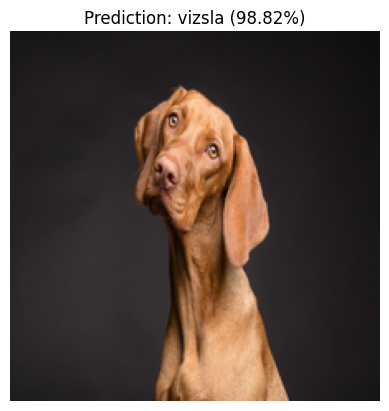

1: vizsla (98.82%)
2: Rhodesian_ridgeback (0.68%)
3: Weimaraner (0.34%)


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, vgg16
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
import requests
from PIL import Image
from io import BytesIO

# Load the pre-trained VGG16 model including the top layers for classification
model = VGG16(weights='imagenet')

# Load a sample image using requests and PIL
# Using a publicly accessible URL for a Golden Retriever image from a different source
img_url = 'https://cdn.pixabay.com/photo/2018/03/31/06/31/dog-3277416_1280.jpg'
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB') # Added .convert('RGB') for consistency
img = img.resize((224, 224)) # Resize to target size

# Preprocess the image
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = vgg16.preprocess_input(img_array)

# Predict the class
preds = model.predict(img_array)

# Decode predictions to human-readable labels
results = vgg16.decode_predictions(preds, top=3)[0]

# Show image and prediction
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {results[0][1]} ({results[0][2]*100:.2f}%)")
plt.show()

# Print top 3 predictions
for i, (imagenet_id, label, score) in enumerate(results):
    print(f"{i+1}: {label} ({score*100:.2f}%)")

## Understanding Backprop-to-image/Deconvolution Methods

Backpropagation-to-image methods (sometimes called **deconvolution methods**) are techniques used to **visualize and interpret deep neural networks**, particularly convolutional neural networks (CNNs). These methods help understand which parts of an input image contribute most to a model's prediction by mapping gradients or activations back onto the input space.

---

### **Why do we need these methods?**

* Deep learning models, especially CNNs, are often treated as “black boxes”.
* Understanding what the model sees or focuses on helps:

  * Debug errors
  * Interpret decisions
  * Build trust in AI
  * Improve model architecture

Backpropagation-to-image methods help reveal which parts of the image activate the model’s neurons the most.

---
### **How Backprop-to-Image Works**

1. **Feed the image through the network → get prediction**
2. **Choose the neuron or output you're interested in**
3. **Compute gradients of that output with respect to the input image**
4. **Propagate these gradients backward through the network**
5. **Map them to the input image space (upsampling if needed)**
6. **Visualize the result as a heatmap or image**

---

### **Example Use Cases**

✔ Detecting areas responsible for misclassifications
✔ Understanding adversarial attacks
✔ Visualizing attention areas in medical imaging
✔ Explaining AI decisions in self-driving cars or surveillance systems

---


### **Core Concepts**

1. **Feature maps and activations**

   * As the image passes through convolutional layers, filters detect patterns (edges, textures).
   * These patterns are stored as feature maps.

2. **Backpropagation of gradients**

   * By computing the gradient of the output with respect to the input image, we can see how sensitive the prediction is to changes in the input pixels.

3. **Mapping back to the image space**

   * The gradients or activations are upsampled or “deconvolved” to match the original image size.
   * The result is a visualization that highlights important regions.

---

### **Popular Methods**

#### 1️⃣ **Deconvolutional Networks (DeconvNet)**

* Instead of normal backpropagation, it reverses the operations layer by layer.
* Applies transposed convolution to feature maps to reconstruct the input.
* Highlights which pixels activate neurons the most.

#### 2️⃣ **Guided Backpropagation**

* Combines standard backpropagation and deconvolution by passing only positive gradients and activations.
* Filters out noise and produces sharper visualizations.

#### 3️⃣ **Grad-CAM (Gradient-weighted Class Activation Mapping)**

* Uses gradients flowing into the last convolutional layer to weigh activations.
* Produces heatmaps showing where the model is looking when making predictions.
* Very popular for explaining CNNs.

---

```python
# The implementation for deconvolution/guided backpropagation is complex
# and often requires custom TensorFlow/PyTorch code. Here's a conceptual
# overview.

# Step 1: Select a neuron from a layer.
# Step 2: Set the neuron's activation to 1 and all others to 0.
# Step 3: Backpropagate this signal to the input image space.
#         Guided backprop ensures gradients are only positive,
#         leading to cleaner visualizations.

# The resulting image will show the pattern that maximally activates
# the selected neuron.
```

-----

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_567']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


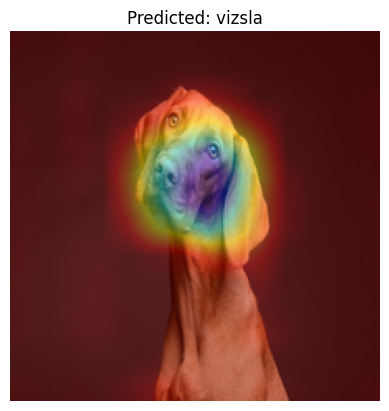

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import VGG16, vgg16
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from io import BytesIO
import requests

# Load pre-trained VGG16 model with top layers for classification
model = VGG16(weights='imagenet')

# Load and preprocess image
img_url = 'https://cdn.pixabay.com/photo/2018/03/31/06/31/dog-3277416_1280.jpg'
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((224, 224))
img_array = image.img_to_array(img)
input_array = np.expand_dims(img_array, axis=0)
input_array = vgg16.preprocess_input(input_array)

# Get predictions
preds = model.predict(input_array)
class_idx = np.argmax(preds[0])
class_output = model.output[:, int(class_idx)]  # Fix: convert to int

# Get the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that maps the input image to the activations of the last conv layer and predictions
grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

# Compute the gradient of the class output with respect to the last conv layer output
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(input_array)
    loss = predictions[:, int(class_idx)]

grads = tape.gradient(loss, conv_outputs)

# Pool the gradients over all axes except the channels
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Multiply each channel in the feature map array by the corresponding gradient
conv_outputs = conv_outputs.numpy()[0]
pooled_grads = pooled_grads.numpy()
for i in range(pooled_grads.shape[0]):
    conv_outputs[:, :, i] *= pooled_grads[i]

# Create the heatmap by averaging all channels
heatmap = np.mean(conv_outputs, axis=-1)

# Normalize the heatmap
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Resize heatmap to match the image size
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))

# Convert heatmap to RGB
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Overlay the heatmap on the original image
superimposed_img = cv2.addWeighted(np.array(img), 0.6, heatmap, 0.4, 0)

# Display the image
plt.imshow(superimposed_img)
plt.axis('off')
plt.title(f"Predicted: {vgg16.decode_predictions(preds, top=1)[0][0][1]}")
plt.show()


### **1. DeconvNet (Deconvolutional Network)**

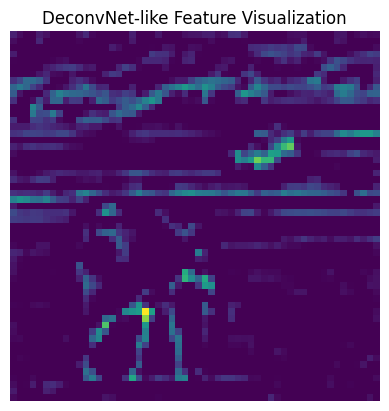

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import requests
from PIL import Image
from io import BytesIO
import cv2

# ['input_layer_5', 'block1_conv1', 'block1_conv2', 'block1_pool', 'block2_conv1', 'block2_conv2', 'block2_pool',
# 'block3_conv1', 'block3_conv2', 'block3_conv3', 'block3_pool', 'block4_conv1', 'block4_conv2', 'block4_conv3',
# 'block4_pool', 'block5_conv1', 'block5_conv2', 'block5_conv3', 'block5_pool', 'flatten', 'fc1', 'fc2', 'predictions']

# Load model and image
model = VGG16(weights='imagenet', include_top=True)
img_url = 'https://cdn.pixabay.com/photo/2024/08/24/14/42/elephant-8994442_960_720.jpg'
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get feature map from first conv layer
layer_name = 'block3_conv1'
layer_output = model.get_layer(layer_name).output
feature_map_model = tf.keras.models.Model(inputs=model.input, outputs=layer_output)
feature_maps = feature_map_model(x)

# Take one channel and visualize as image
activation = feature_maps[0, :, :, 0]
plt.imshow(activation, cmap='viridis')
plt.axis('off')
plt.title("DeconvNet-like Feature Visualization")
plt.show()

### **2. Guided Backpropagation**

Modifies the backpropagation to only allow positive gradients through positive activations.

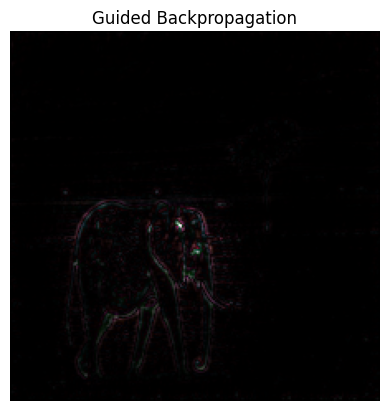

In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import requests
from PIL import Image
from io import BytesIO

# Load model and image
model = VGG16(weights='imagenet', include_top=True)
img_url = 'https://cdn.pixabay.com/photo/2024/08/24/14/42/elephant-8994442_960_720.jpg'
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Define a guided backpropagation function
@tf.custom_gradient
def guided_relu(x):
    def grad(dy):
        # Only allow positive gradients to pass through
        return tf.cast(dy > 0, 'float32') * tf.cast(x > 0, 'float32') * dy
    return tf.nn.relu(x), grad

# Replace activations with guided ReLU
# Need to create a new model to apply the custom activation consistently
layer_dict = dict([(layer.name, layer) for layer in model.layers[1:]]) # Exclude InputLayer
new_model = tf.keras.Sequential()
new_model.add(tf.keras.Input(shape=(224, 224, 3))) # Add InputLayer explicitly

for layer_name in layer_dict.keys():
    layer = layer_dict[layer_name]
    if hasattr(layer, 'activation') and layer.activation == tf.keras.activations.relu:
        # Create a new layer with the same config but guided_relu activation
        config = layer.get_config()
        config['activation'] = guided_relu
        new_layer = layer.__class__.from_config(config)
        new_model.add(new_layer)
        # Transfer weights
        new_layer.set_weights(layer.get_weights())
    else:
        new_model.add(layer)
        # Transfer weights
        if len(layer.get_weights()) > 0:
             new_model.layers[-1].set_weights(layer.get_weights())

# Forward pass and gradient computation
with tf.GradientTape() as tape:
    x_tensor = tf.convert_to_tensor(x, dtype=tf.float32) # Convert to Tensor
    tape.watch(x_tensor)
    preds = new_model(x_tensor) # Use the new model with guided ReLU
    top_class = tf.argmax(preds[0])
    loss = preds[0, top_class]

# Get gradients w.r.t input
grads = tape.gradient(loss, x_tensor)[0] # Use x_tensor for gradient calculation

# Normalize and scale the gradients for visualization
# Take the absolute value of the gradients
grads = tf.abs(grads)

# Normalize each channel independently and then combine
grads = (grads - tf.reduce_min(grads, axis=[0, 1], keepdims=True)) / (tf.reduce_max(grads, axis=[0, 1], keepdims=True) - tf.reduce_min(grads, axis=[0, 1], keepdims=True) + tf.keras.backend.epsilon())
grads = grads * 255 # Scale to 0-255

# Show the guided backpropagation result
# Convert to uint8 for displaying as an image
plt.imshow(grads.numpy().astype(np.uint8))
plt.axis('off')
plt.title("Guided Backpropagation")
plt.show()

### **3. Grad-CAM (Gradient-weighted Class Activation Mapping)**

Uses the gradients flowing into the last convolutional layer to produce a coarse heatmap. Shows which parts of the image are responsible for the prediction.

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: tusker


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_645']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


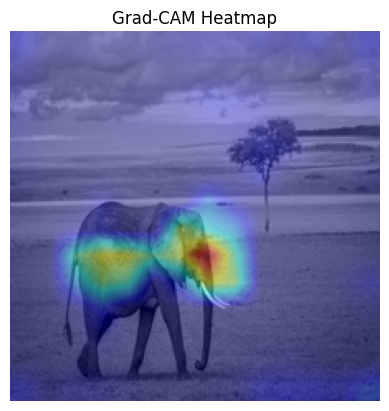

In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions
import cv2

# Load model and image
model = VGG16(weights='imagenet', include_top=True)
img_url = 'https://cdn.pixabay.com/photo/2024/08/24/14/42/elephant-8994442_960_720.jpg'
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Get predictions
preds = model(x)
top_class = tf.argmax(preds[0])
print("Predicted:", decode_predictions(preds, top=1)[0][0][1])

# Get last conv layer output and gradients
last_conv_layer = model.get_layer('block5_conv3')
grad_model = tf.keras.models.Model([model.inputs], [last_conv_layer.output, model.output])

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, top_class]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

# Weight feature maps by importance
conv_outputs = conv_outputs.numpy()[0]
pooled_grads = pooled_grads.numpy()
for i in range(pooled_grads.shape[0]):
    conv_outputs[:, :, i] *= pooled_grads[i]

# Create heatmap
heatmap = np.mean(conv_outputs, axis=-1)
heatmap = np.maximum(heatmap, 0)
heatmap /= np.max(heatmap)

# Overlay heatmap on image
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

img = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# Show final result
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Grad-CAM Heatmap")
plt.show()

### Final Summary

| Method              | Key Idea                                                 | Visualization Type            |
| ------------------- | -------------------------------------------------------- | ----------------------------- |
| **DeconvNet**       | Reverses convolution to reconstruct the input            | Feature maps                  |
| **Guided Backprop** | Allows only positive gradients and activations           | Sharp edges and features      |
| **Grad-CAM**        | Uses last layer gradients to highlight important regions | Heatmap overlaid on the image |

## 🌌 Deep Dream, Hallucination, and Neural Style Transfer

These techniques demonstrate a CNN's learned representations in creative and artistic ways.

  * **Deep Dream:** Starts with an image and iteratively modifies it to enhance the features the network finds, resulting in a surreal, dream-like output. It amplifies the patterns the CNN sees.
  * **Hallucination:** Similar to Deep Dream, but it starts with a blank image and generates an image from scratch that maximally activates certain layers.
  * **Neural Style Transfer:** This is a famous application that combines the content of one image with the style of another. It separates an image's content (e.g., objects) from its style (e.g., texture, color, artistic flair) and recombines them.

<!-- end list -->

```python
# Libraries like TensorFlow Hub or dedicated projects like neural-style-transfer
# simplify this process. Here's a high-level code example.

# This is a complex topic requiring pre-trained models and optimization loops.
# Let's focus on the conceptual steps.

# 1. Load a pre-trained model (e.g., VGG16).
# 2. Define a content image and a style image.
# 3. Create a new image initialized with noise or the content image.
# 4. Use a loss function that combines:
#    - Content Loss: Measures the difference between the new image's
#      activations and the content image's activations.
#    - Style Loss: Measures the difference between the new image's
#      Gram matrix and the style image's Gram matrix.
# 5. Use an optimizer (e.g., Adam) to minimize the total loss,
#    iteratively updating the new image.
```

-----

## 📈 Class Activation Mapping (CAM) and its Variants

CAM-based methods help us understand **where in the image** the network is looking to make a classification decision. They generate a heatmap that highlights the regions most relevant to a specific class.

  * **CAM:** Requires a specific network architecture (Global Average Pooling before the final dense layer). It uses the weights of the final dense layer to create a weighted combination of the feature maps, generating a heatmap.
  * **Grad-CAM:** A more general method that works with any CNN architecture. It uses the gradients of the target class with respect to the final convolutional layer's feature maps to compute the heatmap.
  * **Grad-CAM++:** An improved version of Grad-CAM that provides sharper, more detailed heatmaps by using a weighted combination of positive gradients.

<!-- end list -->

```python
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing import image
import numpy as np
import cv2

# Load the VGG16 model
model = VGG16(weights='imagenet')

# Load and preprocess an image
img_path = tf.keras.utils.get_file('elephant.jpg', 'https://storage.googleapis.com/learning-datasets/elephant.jpg')
img = image.load_img(img_path, target_size=(224, 224))
x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)

# Predict the class
preds = model.predict(x)
predicted_class = np.argmax(preds[0])
print('Predicted class:', decode_predictions(preds, top=1)[0][0][1])

# Get the last convolutional layer
last_conv_layer = model.get_layer('block5_conv3')

# Create a model that outputs both the final prediction and the last conv layer's output
grad_model = tf.keras.models.Model([model.inputs], [model.get_layer(last_conv_layer.name).output, model.output])

# Compute the gradients
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(x)
    loss = predictions[:, predicted_class]

grads = tape.gradient(loss, conv_outputs)[0]

# Compute the weighted average of the gradients
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs_last = conv_outputs[0]

# Create the heatmap
heatmap = conv_outputs_last @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

# Normalize and post-process the heatmap
heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
heatmap = heatmap.numpy()
heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Superimpose heatmap on original image
superimposed_img = heatmap * 0.4 + np.array(img)
superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title('Grad-CAM Heatmap')
plt.axis('off')
plt.show()
```

-----

## 🧠 Recent Methods (IG, Segment-IG, SmoothGrad)

These methods provide more nuanced insights into a model's decisions, often addressing limitations of earlier techniques.

  * **Integrated Gradients (IG):** A method that attributes a prediction to its input features. It calculates the integral of gradients along a straight path from a baseline image (e.g., a black image) to the input image. The result is an attribution map showing the importance of each pixel.
  * **Segment-IG:** An extension of Integrated Gradients that operates on image segments rather than individual pixels, providing a more intuitive and structured explanation.
  * **SmoothGrad:** A technique that addresses the noise and visual clutter in gradient-based saliency maps. It generates multiple saliency maps by adding noise to the input image, and then averages them to create a smoother, more reliable map.